# Main Analysis with Manuscript Figures


### Imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np
from scipy.integrate import odeint
import os
import pandas as pd

## Import the model and default parameters

Model
-----
Generalised Lotka-Volterra system (Eq. 2.1):
\begin{equation}\label{eq:LV} 
\begin{cases}
\frac{dP}{dt} & = r_p \cdot P - \alpha \cdot P\cdot C - \beta \cdot P \cdot M - \eta \cdot P ^2 \\
\frac{dC}{dt}  & = \alpha \cdot P\cdot C - \nu \cdot C^2 \\
\frac{dM}{dt} & = r_m \cdot M - \beta \cdot M \cdot P - \gamma \cdot M^2
\end{cases}
\end{equation} 
where P = public metabolizer, C = cheater, M = private metabolizer.

In [2]:
import sys
sys.path.insert(0, '..')
import src.model
import src.parameters

from src.parameters import parameters
print(parameters)

{'beta': 0.0001, 'gamma': 0.0001, 'alpha': 0.0002, 'eta': 0.0001, 'r_p': 0.5, 'r_m': 0.2, 'nu': 0.0001}


In [3]:
# Simulation settings
Y0          = (100.0, 100.0, 100.0)   # initial conditions (cells)

In [4]:
# ---------------------------------------------------------------------------
# Plotting helper
# ---------------------------------------------------------------------------
def draw_panel(ax, data, ratio_labels, ylabel, title_top, title_bot,
               vmin, vmax, fig, show_cbar):
    """
    Draw a single heatmap panel with extinction overlay.

    Extinct cells (population < EXT_THRESHOLD) are rendered in grey/white;
    the onset of extinction in each row is marked with a dashed red line.
    """
    n_rows = len(MULTIPLIERS)
    is_ext = data < EXT_THRESHOLD

    # --- viridis heatmap (NaN where extinct so grey shows cleanly) ---
    display = np.where(is_ext, np.nan, data)
    im = ax.imshow(
        display,
        aspect="auto", cmap="viridis", origin="lower",
        extent=[t_vec[0], t_vec[-1], 1, n_rows + 1],
        vmin=vmin, vmax=vmax, interpolation="nearest",
    )

    # --- grey/whitish extinction overlay ---
    grey_cmap = mcolors.LinearSegmentedColormap.from_list("ext", ["#e8e8e8", "#f5f5f5"])
    ax.imshow(
        np.where(is_ext, 1.0, np.nan),
        aspect="auto", cmap=grey_cmap, origin="lower",
        extent=[t_vec[0], t_vec[-1], 1, n_rows + 1],
        vmin=0, vmax=1, zorder=2, interpolation="nearest",
    )

    # --- dashed red line at first extinction crossing per row ---
    for row_idx in range(n_rows):
        row_ext = is_ext[row_idx]
        if row_ext.any():
            first_t = t_vec[np.argmax(row_ext)]
            ax.plot(
                [first_t, first_t], [row_idx + 1, row_idx + 2],
                color="#cc2222", linewidth=1.3, linestyle="--", zorder=4,
            )

    # --- colourbar ---
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Cells", fontsize=8)
    cb.ax.tick_params(labelsize=8)

    # --- axes decoration ---
    ax.set_title(f"{title_top}\n{title_bot}", fontsize=10, fontweight="bold", pad=5)
    ax.set_xlabel("Time (h)", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9, fontweight="bold")
    ax.set_yticks(range(1, n_rows + 1))
    ax.set_yticklabels(ratio_labels, fontsize=9)

    return im

## 

## Fig. 2 Impact of different growth conditions on subpopulations

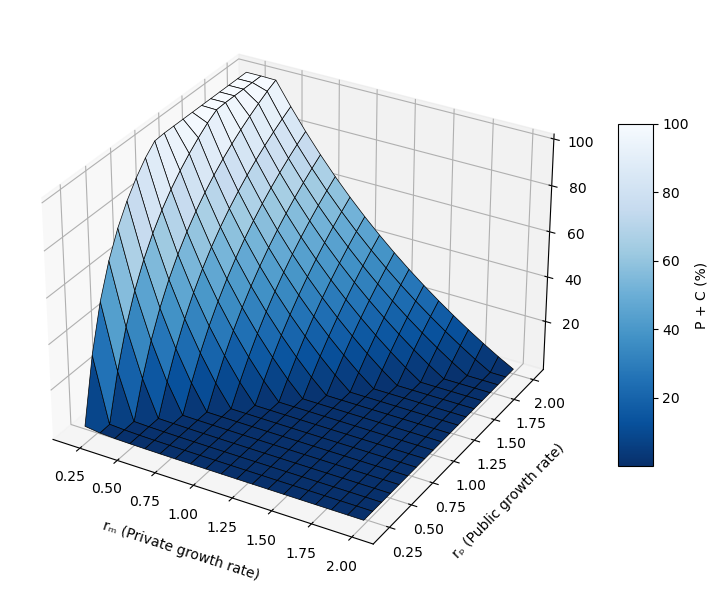

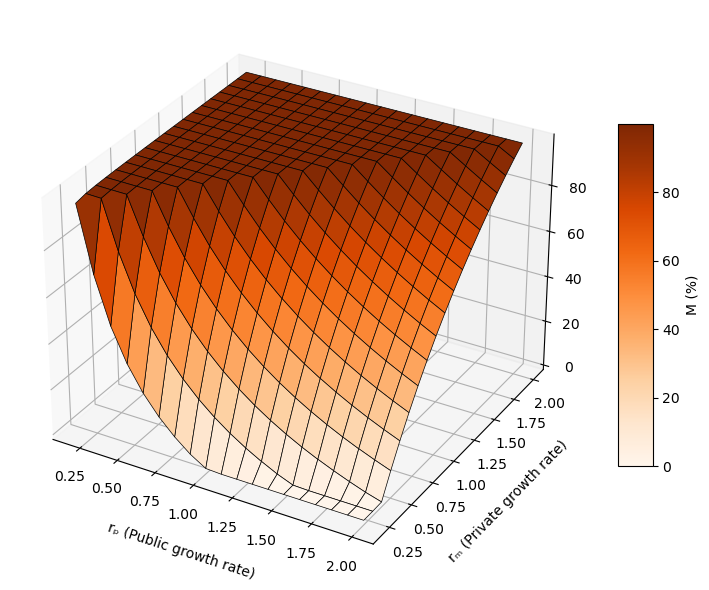

In [5]:
rp_vals = np.linspace(0.2, 2.0, 19)
rm_vals = np.linspace(0.2, 2.0, 19)

def simplex_grid(n=10):
    return np.array([[a/n, b/n, (n-a-b)/n]
                     for a in range(n+1) for b in range(n+1-a)])

grid = simplex_grid()
t = np.linspace(0, 300, 800)

# -------- Simulate Dynamics --------
res = {}
for i, rp in enumerate(rp_vals):
    for j, rm in enumerate(rm_vals):
        p = parameters.copy()
        p['r_p'] = rp
        p['r_m'] = rm
        finals = np.array([odeint(src.model.deriv, Y0, t,
        args=(
            p["nu"], p["beta"], p["alpha"],
            p["r_p"], p["r_m"],
            p["gamma"], p["eta"],
        ),
        rtol=1e-9, atol=1e-11,)[-1] for x0 in grid])
        avg = finals.mean(axis=0)
        res[(i, j)] = {
            'r_p': rp,
            'r_m': rm,
            'prop': avg / avg.sum(),
            'total': avg.sum()
        }

rp_vals_grid, rm_vals_grid = [], []
p_props, c_props, m_props = [], [], []

for (i, j), d in res.items():
    rp_vals_grid.append(d['r_p'])
    rm_vals_grid.append(d['r_m'])
    p_props.append(d['prop'][0])
    c_props.append(d['prop'][1])
    m_props.append(d['prop'][2])

# Reshape to 2D
rp_vals_grid = np.array(rp_vals_grid).reshape(len(rp_vals), len(rm_vals))
rm_vals_grid = np.array(rm_vals_grid).reshape(len(rp_vals), len(rm_vals))
p_props = np.array(p_props).reshape(len(rp_vals), len(rm_vals))
c_props = np.array(c_props).reshape(len(rp_vals), len(rm_vals))
m_props = np.array(m_props).reshape(len(rp_vals), len(rm_vals))

# Compute percentages
pc_props_percent = (p_props + c_props) * 100
m_props_percent = m_props * 100

# -------- Plot P + C (%) with Swapped Axes --------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(rm_vals_grid, rp_vals_grid, pc_props_percent,
                       cmap=cm.Blues_r, edgecolor='k', linewidth=0.5)
ax.set_xlabel('rₘ (Private growth rate)', labelpad=10)
ax.set_ylabel('rₚ (Public growth rate)', labelpad=10)
#ax.set_title('Public (P) + Cheater (C) Population Percentage', pad=15)
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10)
cbar.set_label('P + C (%)')
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(rp_vals_grid, rm_vals_grid, m_props_percent,
                       cmap=cm.Oranges, edgecolor='k', linewidth=0.5)
ax.set_xlabel('rₚ (Public growth rate)', labelpad=10)
ax.set_ylabel('rₘ (Private growth rate)', labelpad=10)


#ax.set_title('Private (M) Population Percentage', pad=15)
cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10)
cbar.set_label('M (%)')
plt.tight_layout()
plt.savefig("output/figures/3d growth rate.png", dpi=300)
plt.show()


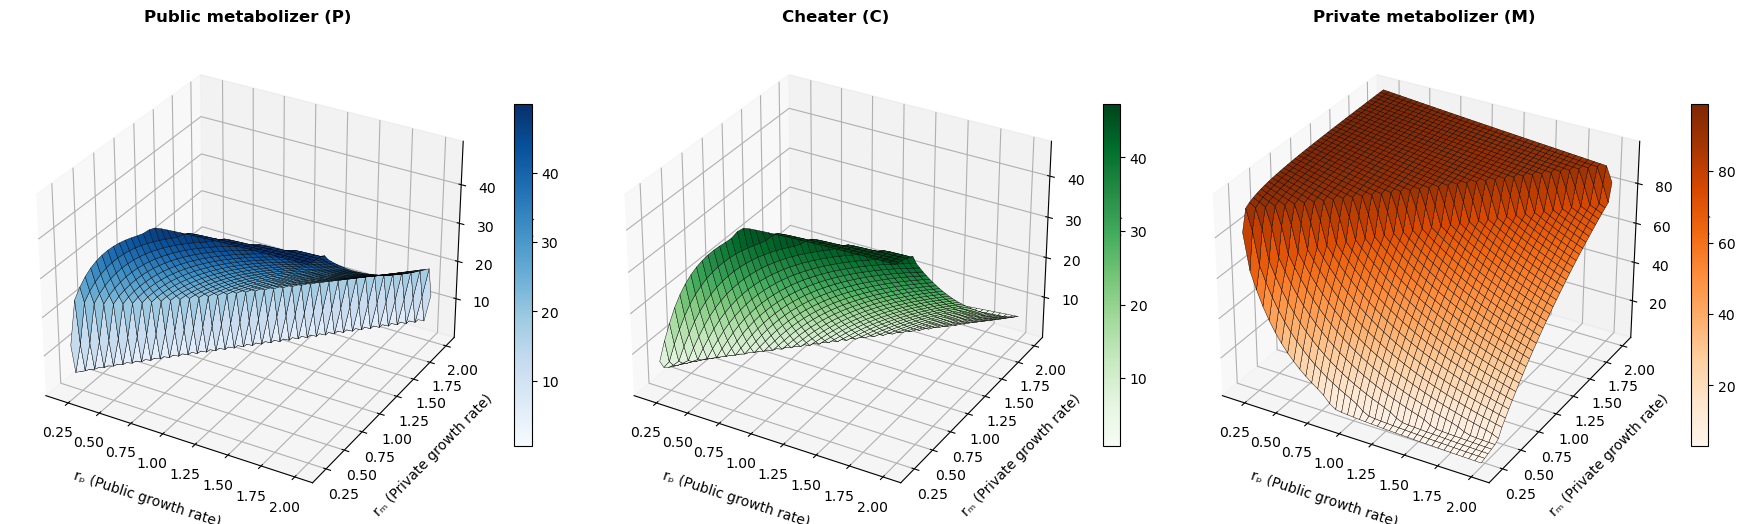

In [6]:
# ============================================================
# Settings
# ============================================================

# Parameter ranges (relative to baseline)
n_points = 40

rp_vals = np.linspace(0.2, 2.0, n_points)
rm_vals = np.linspace(0.2, 2.0, n_points)

# Time and initial conditions
t = np.linspace(0, 300, 800)

def simplex_grid(n=10):
    return np.array([
        [a/n, b/n, (n-a-b)/n]
        for a in range(n+1)
        for b in range(n+1-a)
    ], dtype=float)

grid = simplex_grid(10)

# ============================================================
# Dynamics (uses your parameters dict)
# ============================================================

def dyn(x, t, p):
    P, C, M = x
    return [
        p["r_p"] * P - p["alpha"] * P * C - p["beta"] * P * M - p["eta"] * P**2,
        p["alpha"] * P * C - p["nu"] * C**2,
        p["r_m"] * M - p["beta"] * M * P - p["gamma"] * M**2
    ]

# ============================================================
# Core simulation
# ============================================================

def simulate_average_composition(p, grid, t):
    finals = []

    for x0 in grid:
        sol = odeint(dyn, x0, t, args=(p,))
        final = np.maximum(sol[-1], 0.0)
        finals.append(final)

    finals = np.array(finals)
    avg = finals.mean(axis=0)

    total = avg.sum()
    if total <= 0:
        return np.array([np.nan, np.nan, np.nan])

    return avg / total


# ============================================================
# Parameter scan
# ============================================================

p_props = np.zeros((n_points, n_points))
c_props = np.zeros((n_points, n_points))
m_props = np.zeros((n_points, n_points))

for i, rp in enumerate(rp_vals):
    for j, rm in enumerate(rm_vals):

        p = parameters.copy()
        p["r_p"] = rp
        p["r_m"] = rm

        prop = simulate_average_composition(p, grid, t)

        p_props[i, j] = prop[0]
        c_props[i, j] = prop[1]
        m_props[i, j] = prop[2]

# Convert to %
p_percent = 100 * p_props
c_percent = 100 * c_props
m_percent = 100 * m_props

RP, RM = np.meshgrid(rp_vals, rm_vals, indexing="ij")

# ============================================================
# Plotting
# ============================================================

def plot_surface(ax, X, Y, Z, cmap, title, zlabel):
    surf = ax.plot_surface(
        X, Y, Z,
        cmap=cmap,
        edgecolor='k',
        linewidth=0.3,
        antialiased=True
    )

    ax.set_xlabel('rₚ (Public growth rate)', labelpad=10)
    ax.set_ylabel('rₘ (Private growth rate)', labelpad=10)
    ax.set_zlabel(zlabel, labelpad=10)
    ax.set_title(title, fontweight="bold", pad=12)

    return surf


fig = plt.figure(figsize=(18, 6))

# P
ax1 = fig.add_subplot(131, projection='3d')
surf1 = plot_surface(ax1, RP, RM, p_percent,
                     cm.Blues, "Public metabolizer (P)", "P (%)")
fig.colorbar(surf1, ax=ax1, shrink=0.6)

# C
ax2 = fig.add_subplot(132, projection='3d')
surf2 = plot_surface(ax2, RP, RM, c_percent,
                     cm.Greens, "Cheater (C)", "C (%)")
fig.colorbar(surf2, ax=ax2, shrink=0.6)

# M
ax3 = fig.add_subplot(133, projection='3d')
surf3 = plot_surface(ax3, RP, RM, m_percent,
                     cm.Oranges, "Private metabolizer (M)", "M (%)")
fig.colorbar(surf3, ax=ax3, shrink=0.6)

plt.tight_layout()
plt.savefig("output/figures/3d_growth_rate_clean.png", dpi=300)
plt.show()

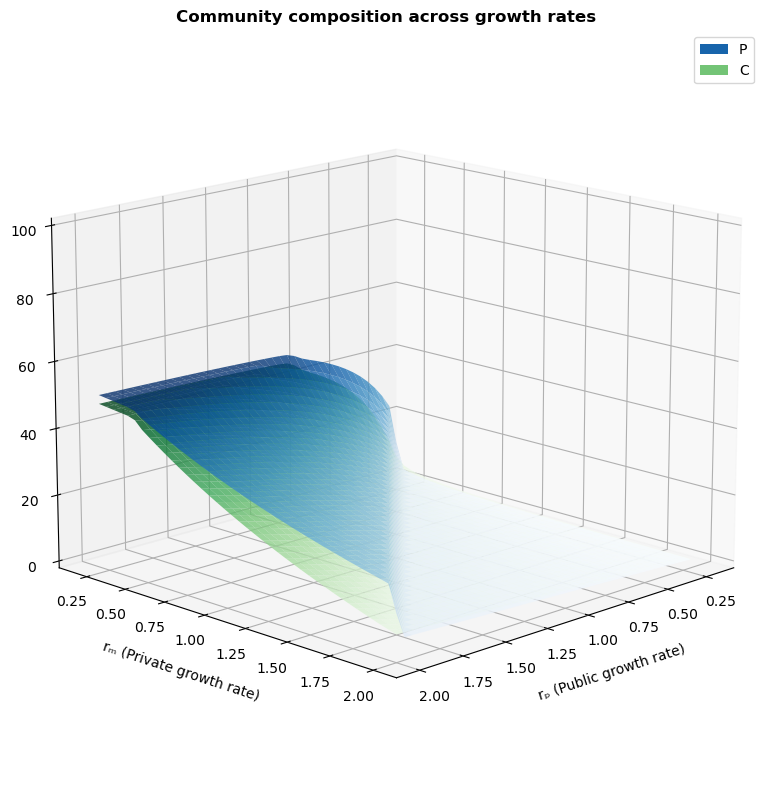

In [7]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Parameter ranges (relative to baseline)
n_points = 40

rp_vals = np.linspace(0.2, 2.0, n_points)
rm_vals = np.linspace(0.2, 2.0, n_points)

RP, RM = np.meshgrid(rp_vals, rm_vals, indexing="ij")

# Convert to percentages
p_percent = p_props * 100
c_percent = c_props * 100
m_percent = m_props * 100

# Plot surfaces with transparency
surf_P = ax.plot_surface(
    RP, RM, p_percent,
    cmap=cm.Blues,
    alpha=0.8,
    linewidth=0,
    antialiased=True
)

surf_C = ax.plot_surface(
    RP, RM, c_percent,
    cmap=cm.Greens,
    alpha=0.8,
    linewidth=0,
    antialiased=True
)

ax.set_xlabel('rₚ (Public growth rate)', labelpad=10)
ax.set_ylabel('rₘ (Private growth rate)', labelpad=10)
ax.set_zlabel('Population fraction (%)', labelpad=10)

ax.set_title('Community composition across growth rates', fontweight="bold")

# Fix z-limits for interpretability
ax.set_zlim(0, 100)

# Custom legend (since colorbars don't make sense now)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=cm.Blues(0.8), label='P'),
    Patch(facecolor=cm.Greens(0.5), label='C'),
]
ax.legend(handles=legend_elements, loc='best')
ax.view_init(elev=15, azim=45)

plt.tight_layout()
plt.savefig("output/figures/3d_overlay_composition.png", dpi=300)
plt.show()

## Fig. 3 Impact of different growth conditions of P and M on population abundance.
Generates Figure 3 from the main text: Impact of interaction coefficient ratios (α:β and β:α) on population dynamics of a tripartite microbial community.


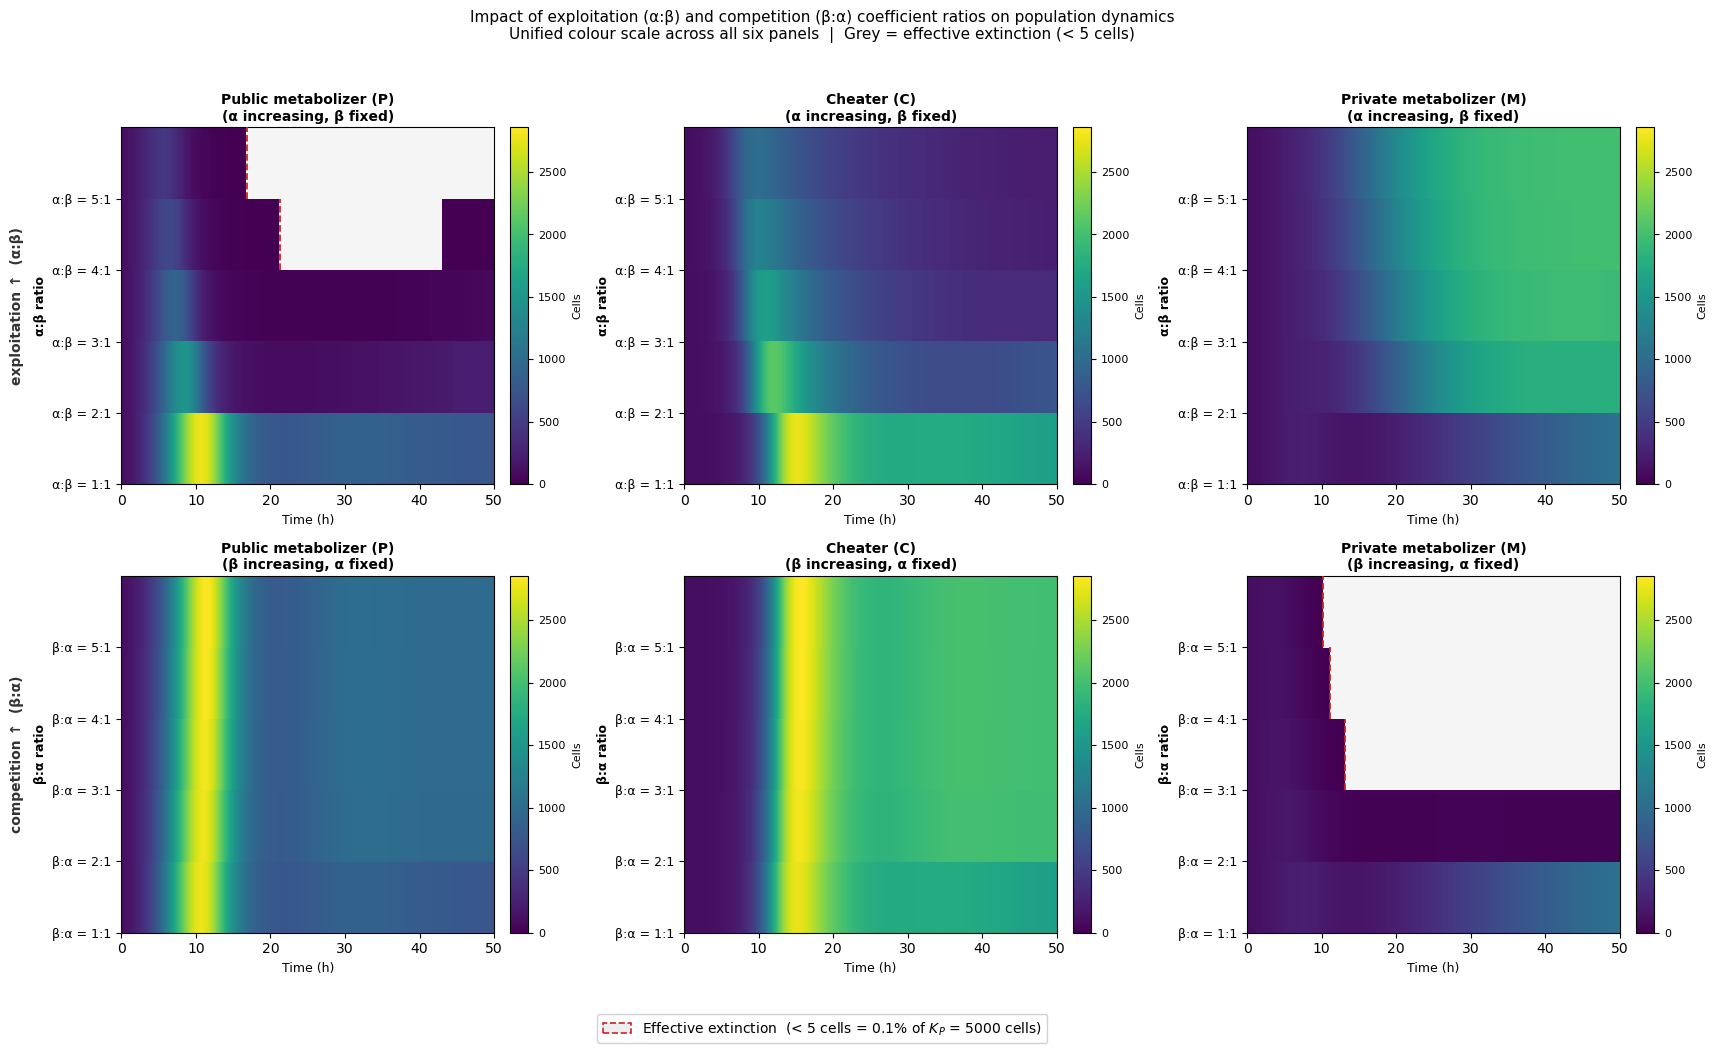

In [8]:
# Carrying capacities implied by the model:
#   K_P = r_p / eta  = 0.5 / 0.0001 = 5000 cells
#   K_M = r_m / gamma = 0.2 / 0.0001 = 2000 cells

T_END       = 50                       # simulation duration (h)
N_TIMEPOINTS = 1000
MULTIPLIERS = [1, 2, 3, 4, 5]         # ratio steps

# Extinction threshold: 0.1% of K_P
K_P = parameters["r_p"] / parameters["eta"]
EXT_THRESHOLD = 0.001 * K_P           # 5 cells

t_vec = np.linspace(0, T_END, N_TIMEPOINTS)

# ---------------------------------------------------------------------------
# Simulation helpers
# ---------------------------------------------------------------------------
def simulate(alpha, beta):
    """Integrate the ODE system for given alpha and beta; return (P, C, M) arrays."""
    sol = odeint(
        src.model.deriv, Y0, t_vec,
        args=(
            parameters["nu"], beta, alpha,
            parameters["r_p"], parameters["r_m"],
            parameters["gamma"], parameters["eta"],
        ),
        rtol=1e-9, atol=1e-11,
    )
    return (
        np.clip(sol[:, 0], 0, None),
        np.clip(sol[:, 1], 0, None),
        np.clip(sol[:, 2], 0, None),
    )


def run_sweep(scale_alpha=False, scale_beta=False):
    """
    Run simulations for each multiplier step.

    Parameters
    ----------
    scale_alpha : bool
        If True, alpha is multiplied by each element of MULTIPLIERS
        (alpha:beta sweep); beta stays at its baseline value.
    scale_beta : bool
        If True, beta is multiplied by each element of MULTIPLIERS
        (beta:alpha sweep); alpha stays at its baseline value.

    Returns
    -------
    dict with keys "P", "C", "M", each a 2-D array of shape
    (len(MULTIPLIERS), N_TIMEPOINTS).
    """
    pop = {k: np.zeros((len(MULTIPLIERS), N_TIMEPOINTS)) for k in ("P", "C", "M")}
    for i, k in enumerate(MULTIPLIERS):
        a = parameters["alpha"] * k if scale_alpha else parameters["alpha"]
        b = parameters["beta"]  * k if scale_beta  else parameters["beta"]
        P, C, M = simulate(a, b)
        pop["P"][i] = P
        pop["C"][i] = C
        pop["M"][i] = M
    return pop

# Run both sweeps
pop_alpha = run_sweep(scale_alpha=True,  scale_beta=False)   # α:β → upper row
pop_beta  = run_sweep(scale_alpha=False, scale_beta=True)    # β:α → lower row

# Unified colour scale across all six panels
all_values = np.concatenate([v.ravel() for pop in (pop_alpha, pop_beta)
                                        for v in pop.values()])
VMIN, VMAX = 0.0, float(all_values.max())

# Row and column labels
alpha_labels = [f"α:β = {k}:1" for k in MULTIPLIERS]
beta_labels  = [f"β:α = {k}:1" for k in MULTIPLIERS]
pop_keys     = ["P",                        "C",          "M"]
pop_titles   = ["Public metabolizer (P)", "Cheater (C)", "Private metabolizer (M)"]

# Build figure
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor("white")

for col, (key, ptitle) in enumerate(zip(pop_keys, pop_titles)):
    # Upper row: α:β (exploitation) sweep
    draw_panel(
        ax=axs[0, col], data=pop_alpha[key],
        ratio_labels=alpha_labels, ylabel="α:β ratio",
        title_top=ptitle, title_bot="(α increasing, β fixed)",
        vmin=VMIN, vmax=VMAX, fig=fig, show_cbar=True,
    )
    # Lower row: β:α (competition) sweep
    draw_panel(
        ax=axs[1, col], data=pop_beta[key],
        ratio_labels=beta_labels,  ylabel="β:α ratio",
        title_top=ptitle, title_bot="(β increasing, α fixed)",
        vmin=VMIN, vmax=VMAX, fig=fig, show_cbar=True,
    )

# Row banners
for ax_row, label in zip(
    [axs[0, 0], axs[1, 0]],
    ["exploitation ↑  (α:β)", "competition ↑  (β:α)"],
):
    ax_row.annotate(
        label, xy=(-0.28, 0.5), xycoords="axes fraction",
        fontsize=10, fontweight="bold", color="#333333",
        rotation=90, va="center", ha="center",
    )

# Shared extinction legend
ext_patch = mpatches.Patch(
    facecolor="#eeeeee", edgecolor="#cc2222", linestyle="--", linewidth=1.2,
    label=(f"Effective extinction  "
            f"(< {EXT_THRESHOLD:.0f} cells = 0.1% of $K_P$ = {K_P:.0f} cells)"),
)
fig.legend(
    handles=[ext_patch], loc="lower center",
    fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    "Impact of exploitation (α:β) and competition (β:α) coefficient ratios "
    "on population dynamics\n"
    f"Unified colour scale across all six panels  |  "
    f"Grey = effective extinction (< {EXT_THRESHOLD:.0f} cells)",
    fontsize=11, y=1.02,
)

plt.tight_layout(rect=[0.04, 0.04, 1, 1])
plt.show()



In [9]:
# ---------------------------------------------------------------------------
# Diagnostic summary
# ---------------------------------------------------------------------------

print(f"\nExtinction threshold: {EXT_THRESHOLD:.1f} cells  "
        f"(0.1% of K_P = {K_P:.0f})")
print(f"Unified colour scale: [{VMIN:.0f}, {VMAX:.0f}] cells\n")

def ext_flag(v):
    return "EXT" if v < EXT_THRESHOLD else "ok"

for label, pop_data, rlabels in [
    ("α:β sweep (upper row)", pop_alpha, alpha_labels),
    ("β:α sweep (lower row)", pop_beta,  beta_labels),
]:
    print(label)
    print(f"  {'Ratio':>10}  {'P_final':>10}  {'C_final':>10}  "
            f"{'M_final':>10}  {'P?':>5}  {'C?':>5}  {'M?':>5}")
    print("  " + "─" * 65)
    for i, rl in enumerate(rlabels):
        P = pop_data["P"][i, -1]
        C = pop_data["C"][i, -1]
        M = pop_data["M"][i, -1]
        print(f"  {rl:>10}  {P:>10.2f}  {C:>10.2f}  {M:>10.2f}  "
                f"{ext_flag(P):>5}  {ext_flag(C):>5}  {ext_flag(M):>5}")
    print()


Extinction threshold: 5.0 cells  (0.1% of K_P = 5000)
Unified colour scale: [0, 2856] cells

α:β sweep (upper row)
       Ratio     P_final     C_final     M_final     P?     C?     M?
  ─────────────────────────────────────────────────────────────────
   α:β = 1:1      768.08     1599.44     1069.58     ok     ok     ok
   α:β = 2:1      222.07      754.97     1787.50     ok     ok     ok
   α:β = 3:1       75.25      341.71     1945.38     ok     ok     ok
   α:β = 4:1        9.83      238.05     1990.54     ok     ok     ok
   α:β = 5:1        1.31      213.17     1996.58    EXT     ok     ok

β:α sweep (lower row)
       Ratio     P_final     C_final     M_final     P?     C?     M?
  ─────────────────────────────────────────────────────────────────
   β:α = 1:1      768.08     1599.44     1069.58     ok     ok     ok
   β:α = 2:1      989.58     1978.30       21.90     ok     ok     ok
   β:α = 3:1      998.50     1995.51        0.08     ok     ok    EXT
   β:α = 4:1      998.45 

## Fig. 6 Numerical lab evolution (shift in population)

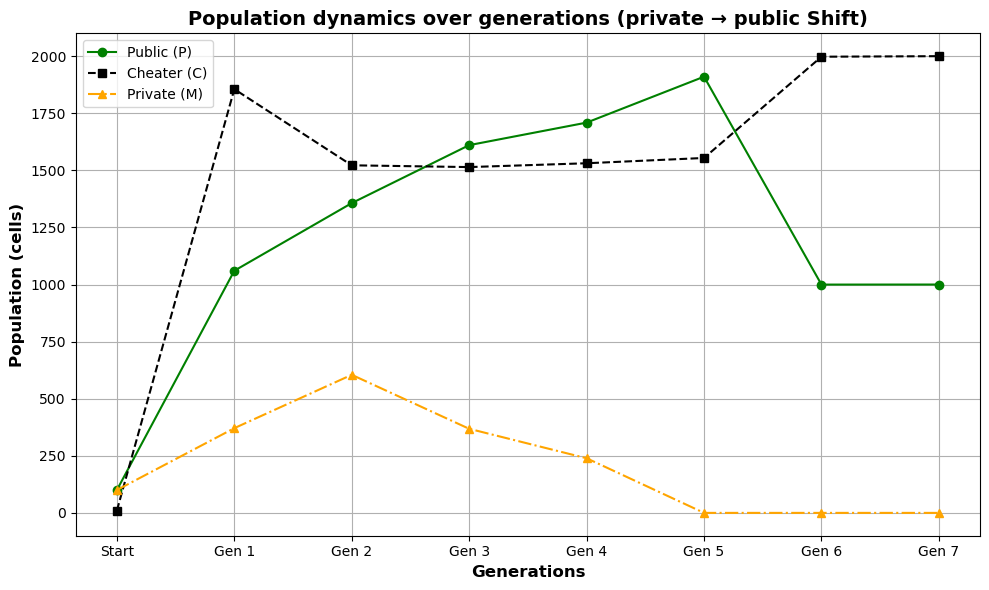

In [10]:
# **Time settings**
T = 40  # Total simulation time for each generation
dt = 0.1
time = np.linspace(0, T, int(T/dt))

# **Initial conditions** (before Generation 1 starts)
P_init, C_init, M_init = 100, 10, 100  # Initial population values
generations = ["Start", "Gen 1", "Gen 2", "Gen 3", "Gen 4", "Gen 5", "Gen 6","Gen 7"]

# **Store population values for plotting**
public_pop = [P_init]   # Store initial Public (P) population
cheater_pop = [C_init]  # Store initial Cheater (C) population
private_pop = [M_init]  # Store initial Private (M) population
total_pop = [P_init + C_init + M_init]  # Track total population

# **Define transition rates for each generation (Private → Public shift)**
shift_ratios = [0.3, 0.5, 0.7, 0.8, 1, 0, 0]  # Shift percentages

# **Run simulation for each generation**
y0 = [P_init, C_init, M_init]  # Initial population
for shift in shift_ratios:
    # **Run simulation for the current generation**
    sol = odeint(src.model.deriv, y0, time, args=(
        parameters["nu"],
        parameters["beta"],
        parameters["alpha"],
        parameters["r_p"],
        parameters["r_m"],
        parameters["gamma"],
        parameters["eta"],
    ))

    # **Extract final population values at the end of the generation**
    final_P, final_C, final_M = sol[-1]

    # **Modify population for next generation shift**
    new_P = final_P + (final_M * shift)  # Public receives shifted Private
    new_M = final_M * (1 - shift)  # Private decreases
    new_C = final_C  # Cheater remains unchanged

    # **Store values for plotting**
    public_pop.append(new_P)
    private_pop.append(new_M)
    cheater_pop.append(new_C)
    total_pop.append(new_P + new_C + new_M)  # Compute total population

    # **Update initial conditions for next generation**
    y0 = [new_P, new_C, new_M]

# **Plot Results**
plt.figure(figsize=(10, 6))

# **Ensure lists have the same length**
if len(generations) == len(public_pop):
    # **Plot Public  shift**
    plt.plot(generations, public_pop, marker="o", linestyle="-", color="green", label="Public (P)")

    # **Plot Cheater population**
    plt.plot(generations, cheater_pop, marker="s", linestyle="--", color="black", label="Cheater (C)")

    # **Plot Private population**
    plt.plot(generations, private_pop, marker="^", linestyle="-.", color="orange", label="Private (M)")

    # **Formatting**
    plt.xlabel("Generations", fontsize=12, fontweight="bold")
    plt.ylabel("Population (cells)", fontsize=12, fontweight="bold")
    plt.title("Population dynamics over generations (private → public Shift)", fontsize=14, fontweight="bold")
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.tight_layout()

    # **Save & show the figure**
    plt.savefig("output/figures/private_to_public_shift.png", dpi=300)
    plt.show()
else:
    print(f"Mismatch: Generations ({len(generations)}) vs Population Data ({len(public_pop)})")


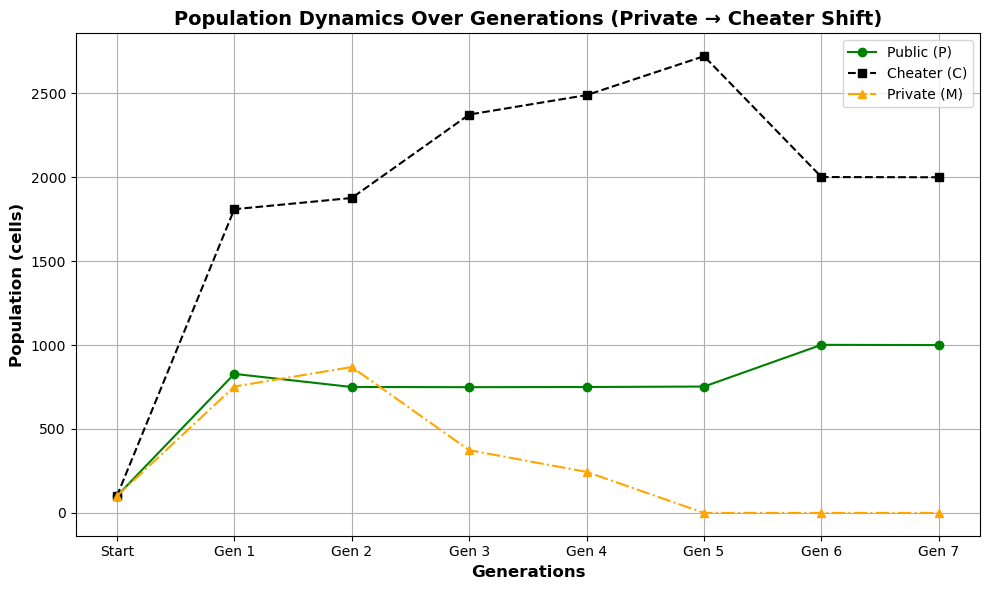

In [11]:
# **Time settings**
T = 40  # Total simulation time for each generation
dt = 0.1
time = np.linspace(0, T, int(T/dt))

# **Initial conditions** (before Generation 1 starts)
C_init, D_init, P_init = 100, 10, 100  # Initial population values
generations = ["Start", "Gen 1", "Gen 2", "Gen 3", "Gen 4", "Gen 5", "Gen 6","Gen 7"]

# **Store population values for plotting**
public_pop = [P_init]   # Store initial Public (P) population
cheater_pop = [C_init]  # Store initial Cheater (C) population
private_pop = [M_init]  # Store initial Private (M) population
total_pop = [P_init + C_init + M_init]  # Track total population

# **Define transition rates for each generation (Private → Cheater shift)**
shift_ratios = [0.1, 0.3, 0.7, 0.8, 1.0, 0,0]  # Shift percentages

# **Run simulation for each generation**
y0 = [P_init, C_init, M_init]  # Initial population
for shift in shift_ratios:
    # **Run simulation for the current generation**
    sol = odeint(src.model.deriv, y0, time, args=(
        parameters["nu"],
        parameters["beta"],
        parameters["alpha"],
        parameters["r_p"],
        parameters["r_m"],
        parameters["gamma"],
        parameters["eta"],
    ))

    # **Extract final population values at the end of the generation**
    final_P, final_C, final_M = sol[-1]

    # **Modify population for next generation shift**
    new_C = final_C + (final_M * shift)  # Cheater receives shifted Private
    new_M = final_M * (1 - shift)  # Private decreases
    new_P = final_P  # Public remains unchanged

    # **Store values for plotting**
    public_pop.append(new_P)
    private_pop.append(new_M)
    cheater_pop.append(new_C)
    total_pop.append(new_P + new_C + new_M)  # Compute total population

    # **Update initial conditions for next generation**
    y0 = [new_P, new_C, new_M]

# **Plot Results**
plt.figure(figsize=(10, 6))

# **Ensure lists have the same length**
if len(generations) == len(public_pop):
    # **Plot Public shift**
    plt.plot(generations, public_pop, marker="o", linestyle="-", color="green", label="Public (P)")

    # **Plot Cheater  population**
    plt.plot(generations, cheater_pop, marker="s", linestyle="--", color="black", label="Cheater (C)")

    # **Plot Private  population**
    plt.plot(generations, private_pop, marker="^", linestyle="-.", color="orange", label="Private (M)")

    # **Formatting**
    plt.xlabel("Generations", fontsize=12, fontweight="bold")
    plt.ylabel("Population (cells)", fontsize=12, fontweight="bold")
    plt.title("Population Dynamics Over Generations (Private → Cheater Shift)", fontsize=14, fontweight="bold")
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.tight_layout()

    # **Save & show the figure**
    plt.savefig("output/figures/private_to_cheater_shift.png", dpi=300)
    plt.show()
else:
    print(f"Mismatch: Generations ({len(generations)}) vs Population Data ({len(public_pop)})")


# Supplementary Material
Simulating with different initial ratio(cheater 1:5:10)


In [12]:
# Define initial conditions for different ratios
ratios = {
    "1:1:1": [100.0, 100.0, 100.0],  # C:D:P
    "1:5:1": [100.0, 500.0, 100.0],
    "1:10:1": [100.0, 1000.0, 100.0],
}

# Time points
t = np.linspace(0, 200, 500)


# Ensure output directory exists
os.makedirs("output/figures", exist_ok=True)

# Define colors for populations and line styles for ratios
colors = {"Public (P)": "green", "Cheater (C)": "black", "Private (M)": "orange"}
line_styles = {
    "1:1:1": "-",
    "1:5:1": "--",
    "1:10:1": ":",
}

def simulate_population(t, ratios, colors, line_styles, parameters, save_name_suffix):

    for population, idx in zip(["Public (P)", "Cheater (C)", "Private (M)"], range(3)):
        plt.figure(figsize=(10, 6))
        for label, y0 in ratios.items():
            # Solve the system of ODEs
            ret = odeint(src.model.deriv, y0, t, args=(
                parameters["nu"],
                parameters["beta"],
                parameters["alpha"],
                parameters["r_p"],
                parameters["r_m"],
                parameters["gamma"],
                parameters["eta"],
            ))
            
            # Plot the specific population with the correct color and line style
            legend_label = f"Public:Cheater:Private - {label}"
            plt.plot(
                t, ret[:, idx],
                color=colors[population],  # Correct color applied here
                linestyle=line_styles[label],  # Line style for the ratio
                label=legend_label
            )

        # Customize the plot
        plt.xlabel("Time(h)", fontsize=14, fontweight="bold")
        plt.ylabel("Population(cell)", fontsize=14,fontweight="bold" )
        plt.title(f"{population} Population Dynamics", fontsize=16)
        plt.legend(title="Initial Ratios", fontsize=10)
        plt.grid()
        plt.tight_layout()

        # Save the figure with a suffix to distinguish results
        output_file = f"output/figures/{population.replace(' ', '_').lower()}_{save_name_suffix}.png"
        plt.savefig(output_file, dpi=300)
        plt.show()


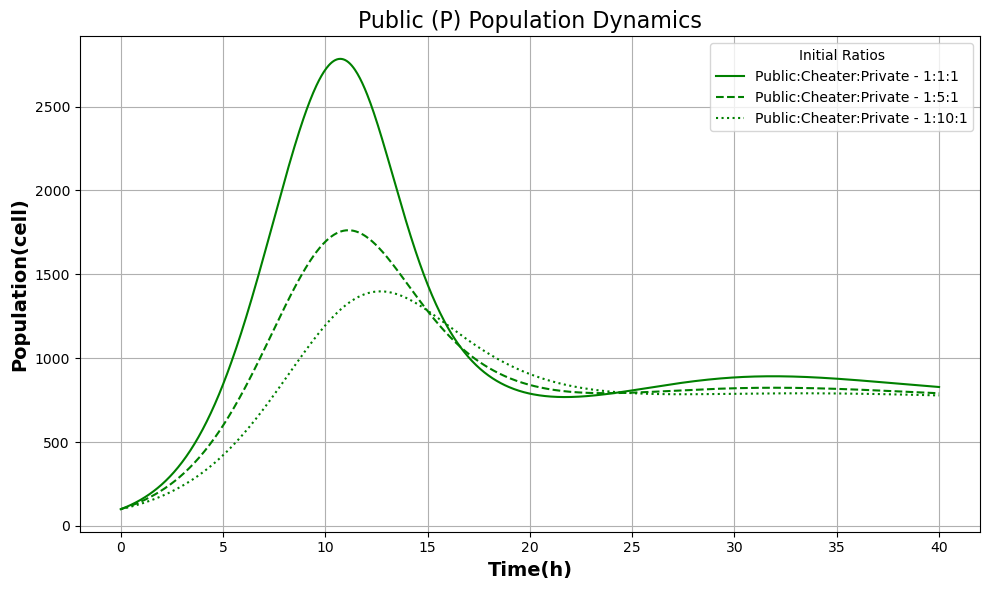

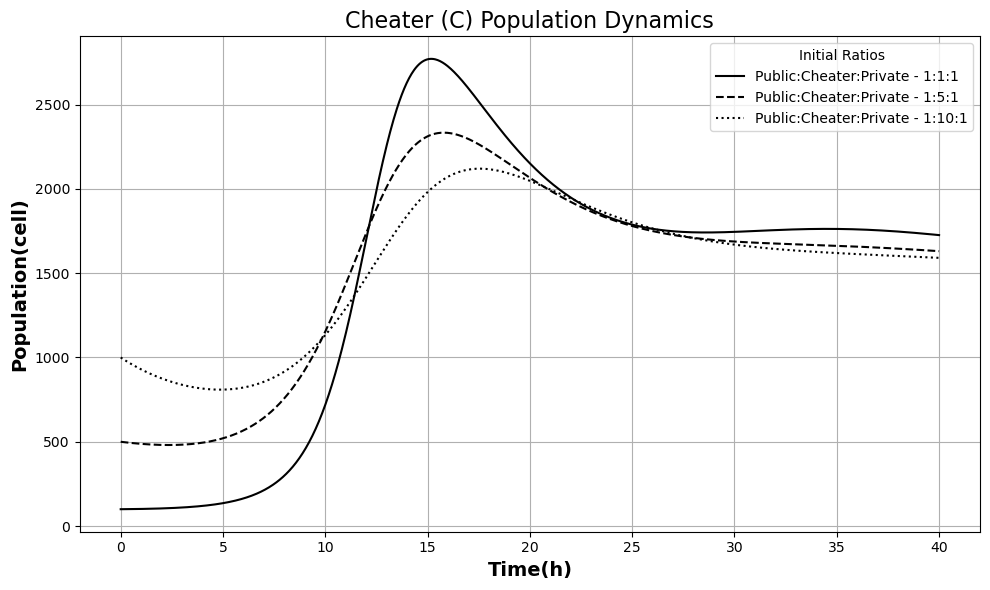

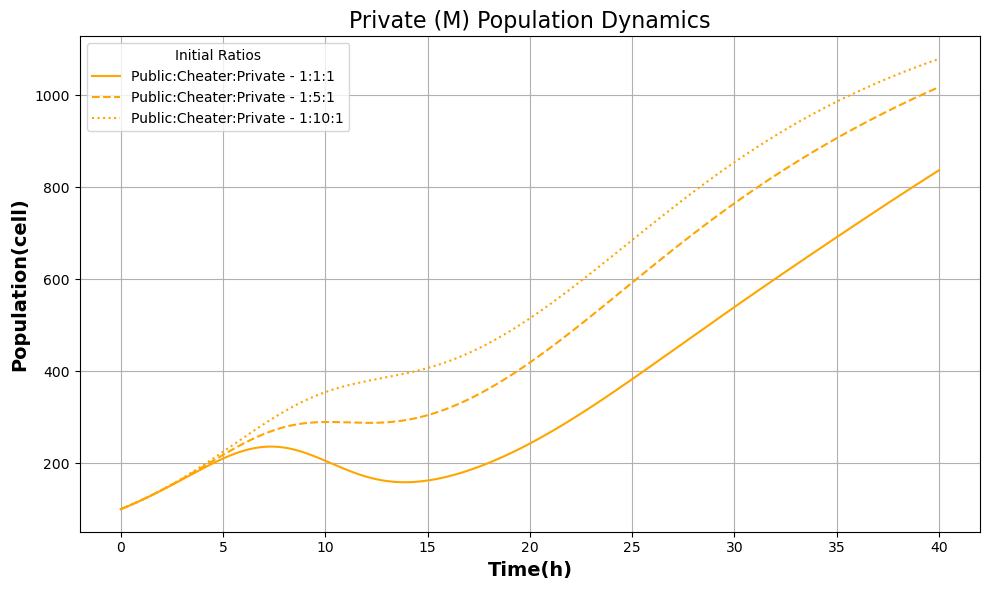

In [13]:
t_updated = np.linspace(0, 40, 1000)
simulate_population(t_updated, ratios, colors, line_styles, parameters, save_name_suffix="cheater_ra")

## longer time period

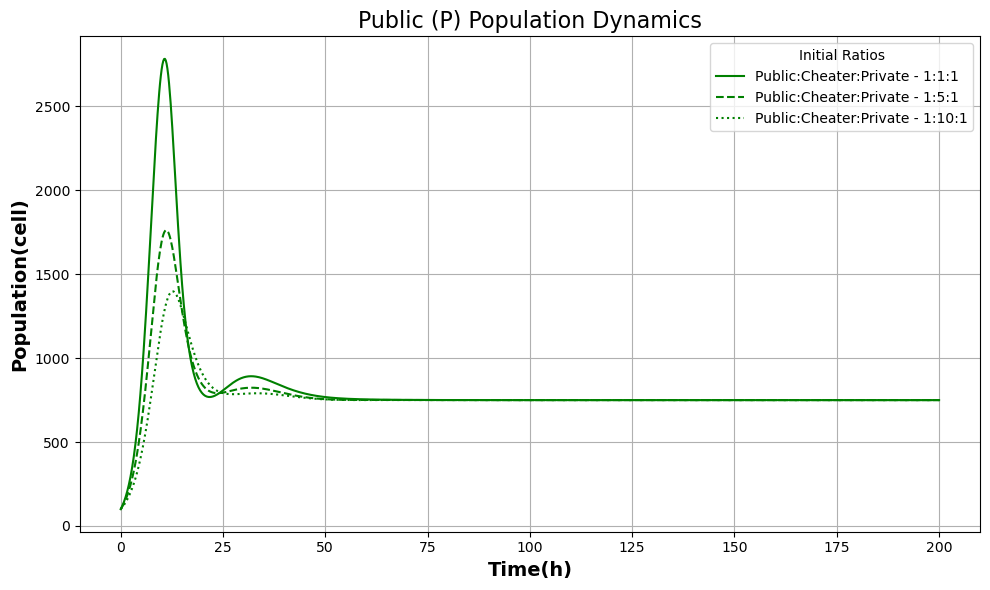

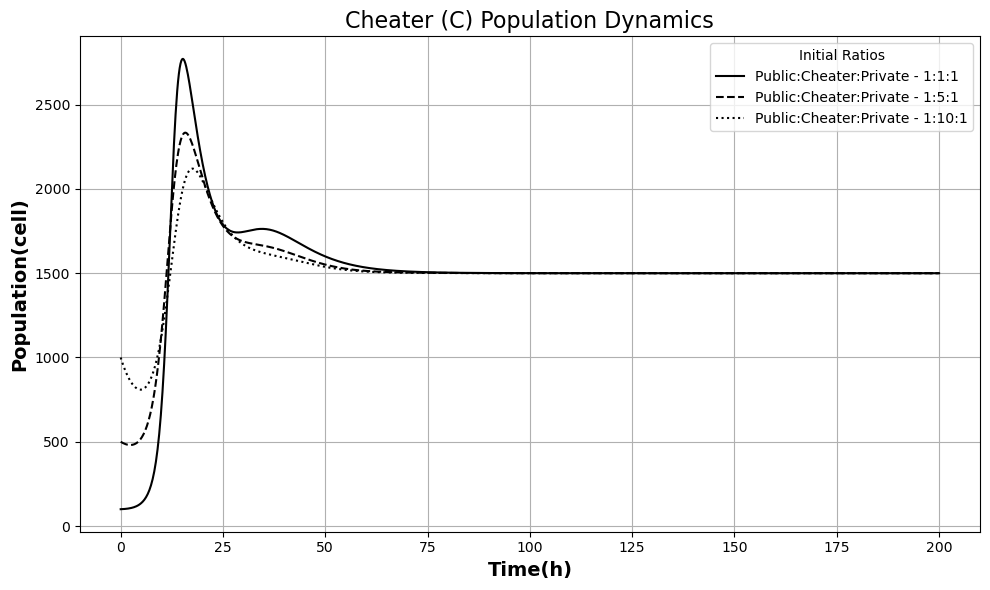

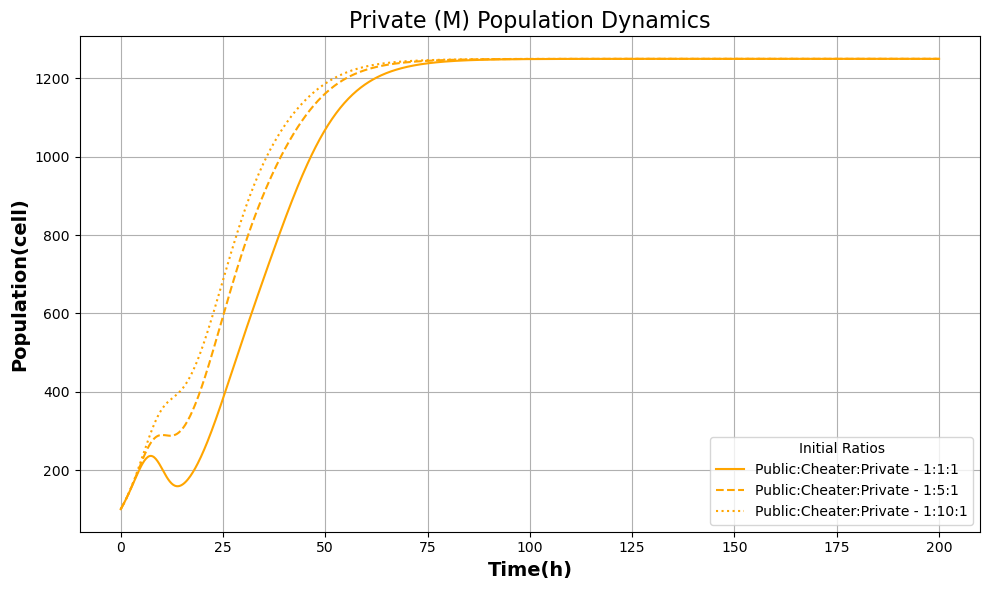

In [14]:
t_updated = np.linspace(0, 200, 1000)
simulate_population(t_updated, ratios, colors, line_styles, parameters, save_name_suffix="updated_time")

## higher ratio of public population(1:5:10)

In [15]:
# Updated ratios: Public (C) has initial ratio of 1, 5, and 10
ratios_updated = {
    "1:1:1": [100.0, 100.0, 100.0],  # C:D:P
    "5:1:1": [500.0, 100.0, 100.0],
    "10:1:1": [1000.0, 100.0, 100.0],
}

line_styles = {
    "1:1:1": "-",
    "5:1:1": "--",
    "10:1:1": ":",
}


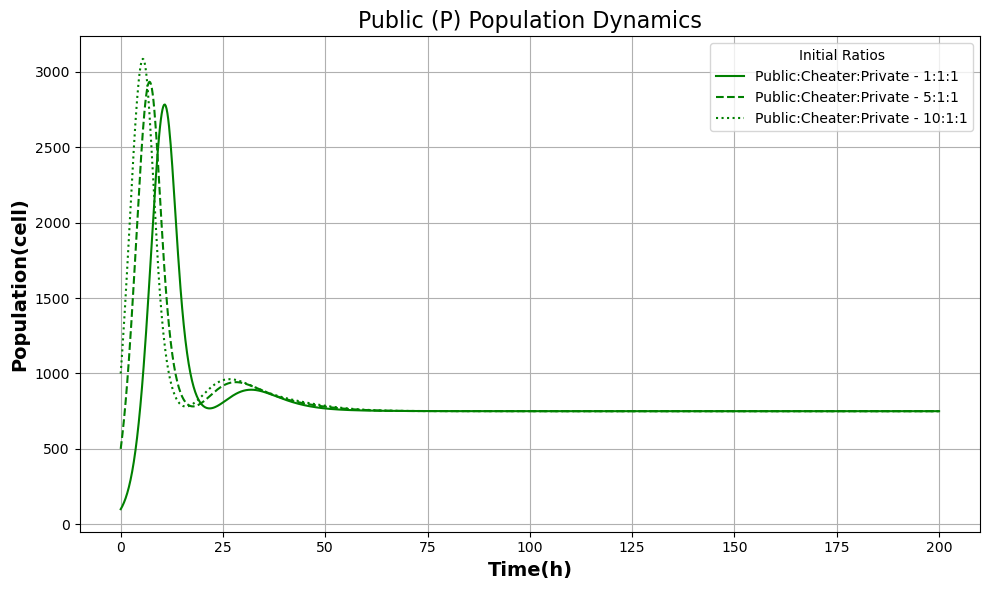

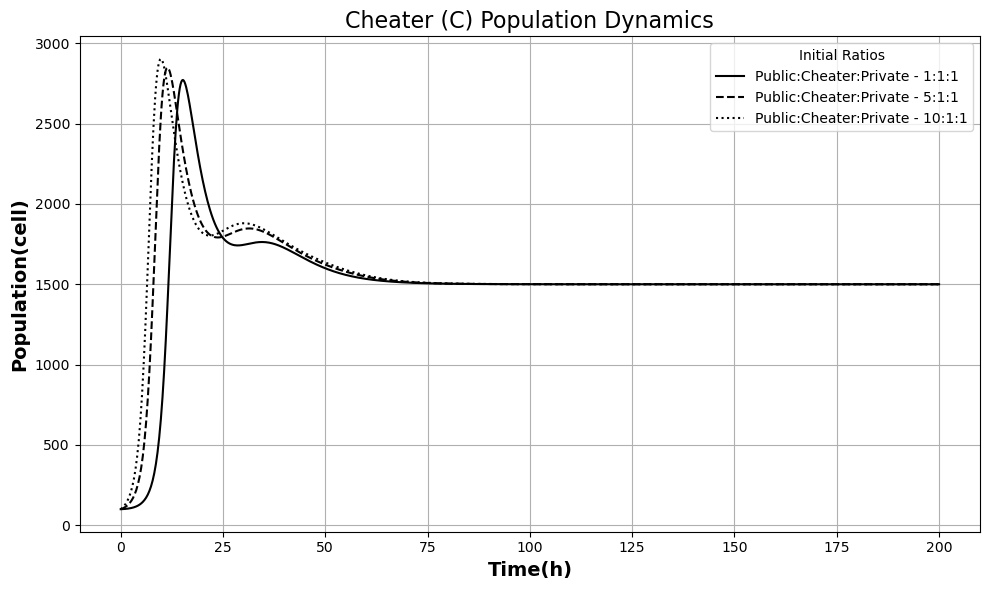

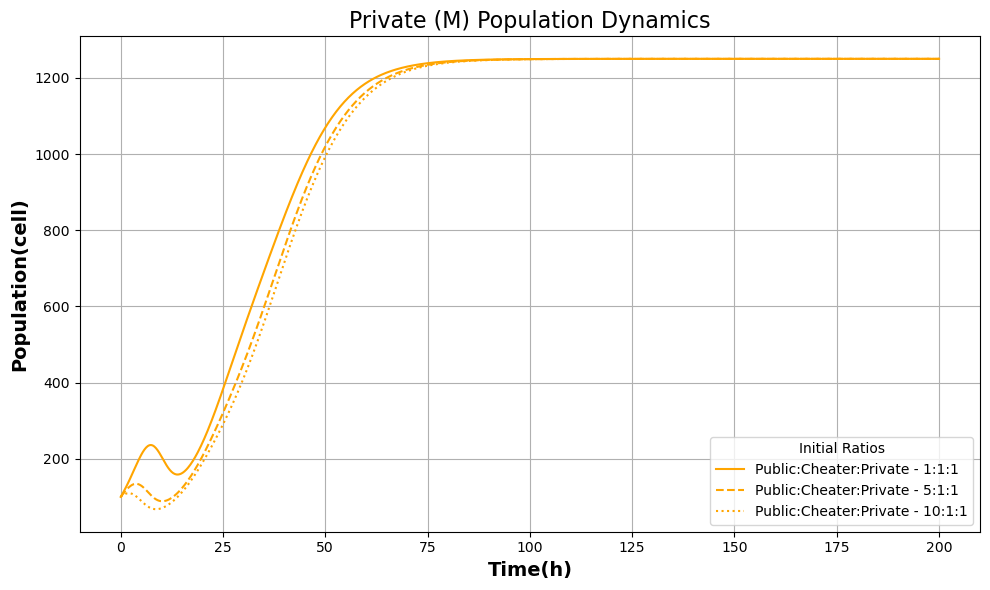

In [16]:
simulate_population(t_updated, ratios_updated, colors, line_styles, parameters, save_name_suffix="public_ratio")

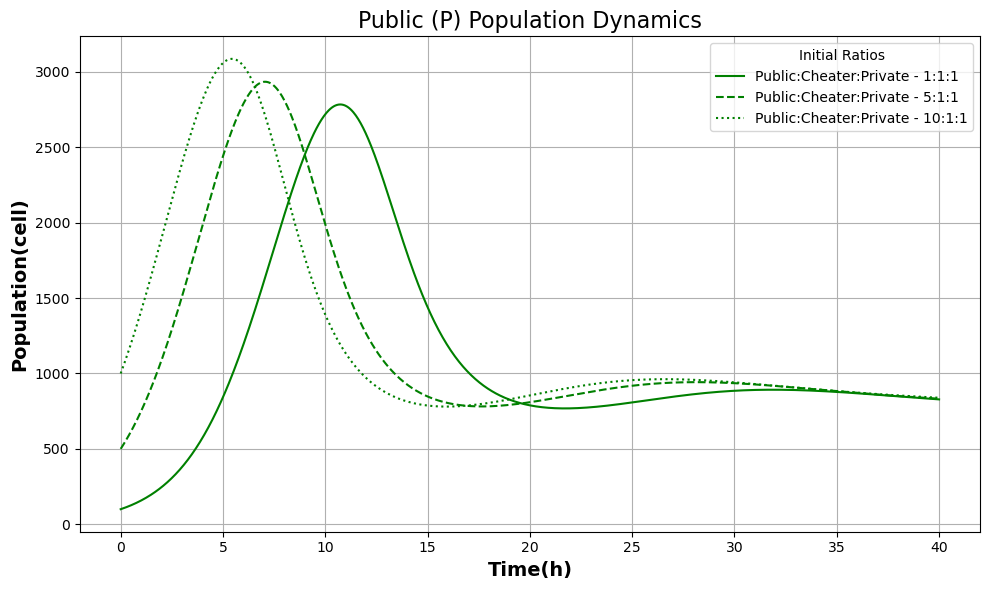

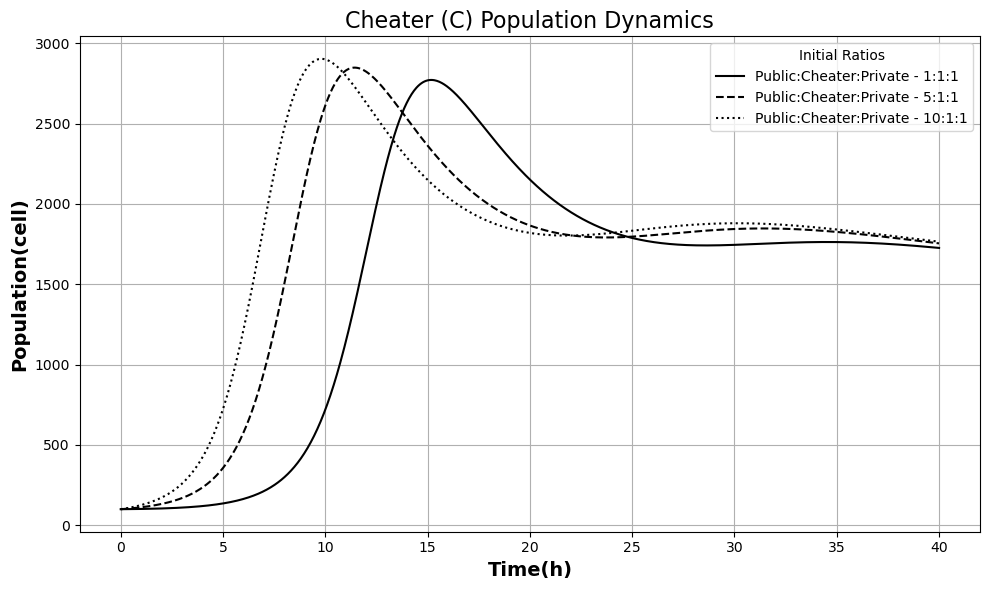

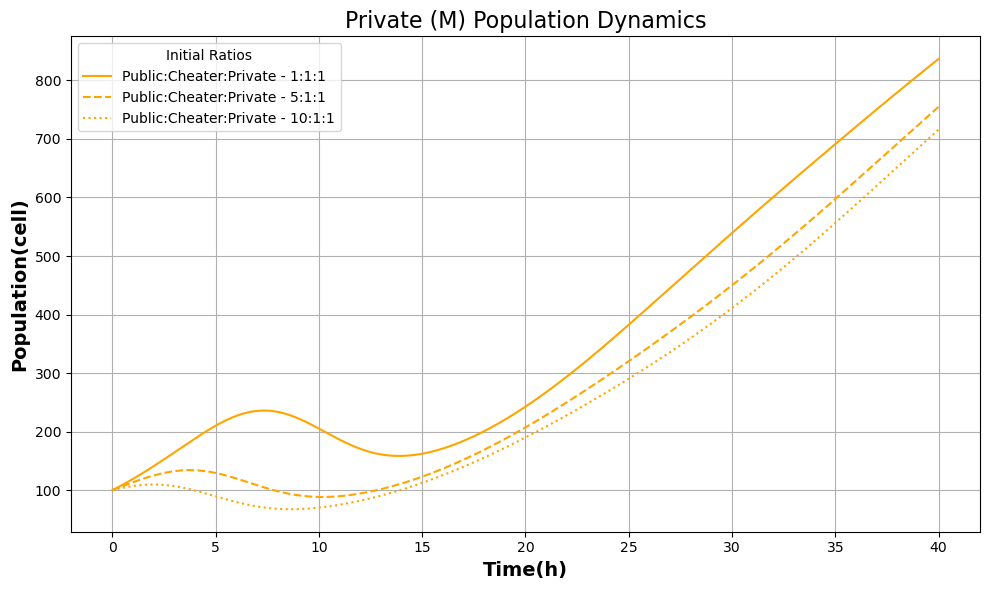

In [17]:
t_updated = np.linspace(0, 40, 1000)
simulate_population(t_updated, ratios_updated, colors, line_styles, parameters, save_name_suffix="public_ratio")

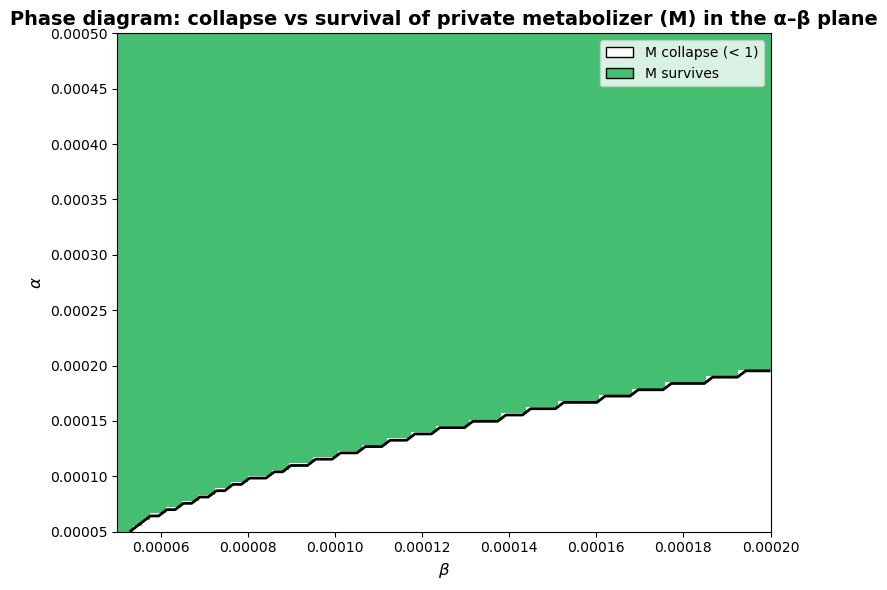

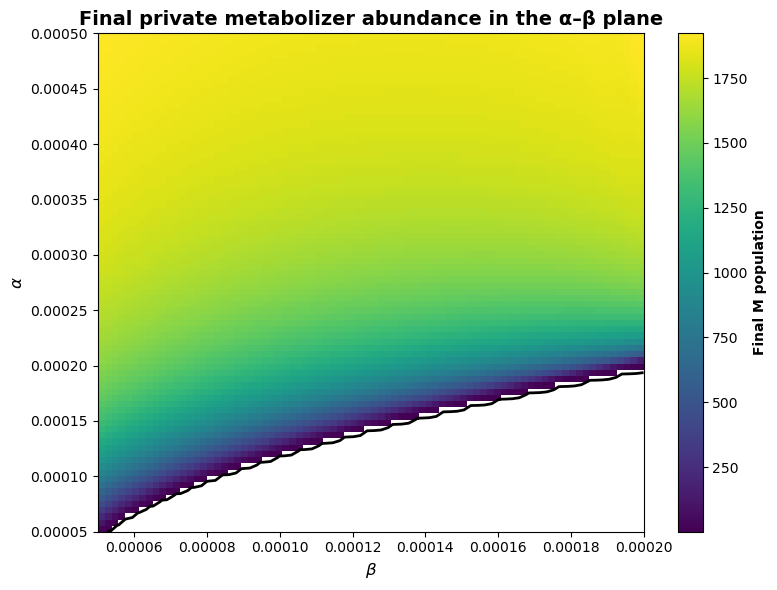

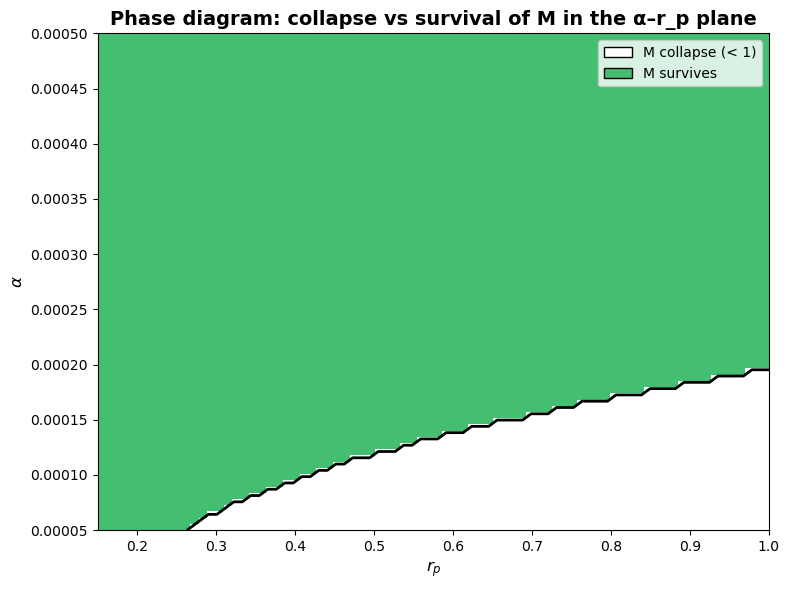

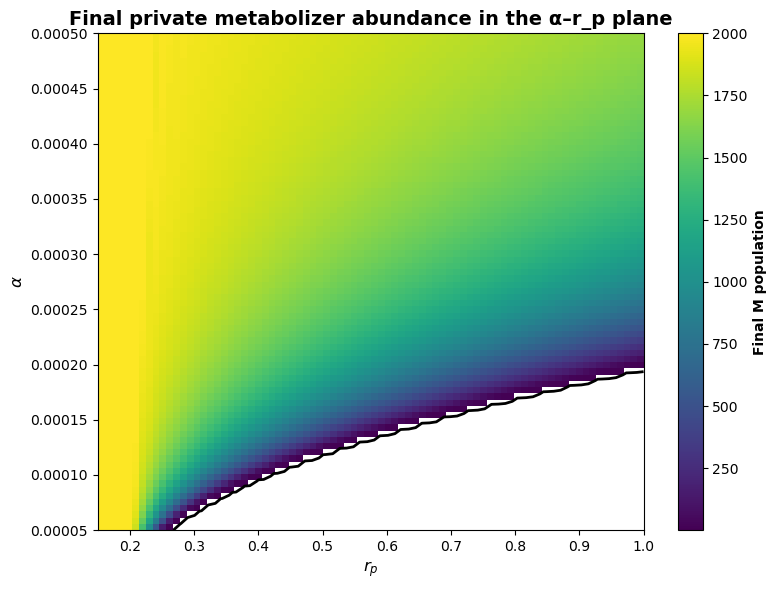

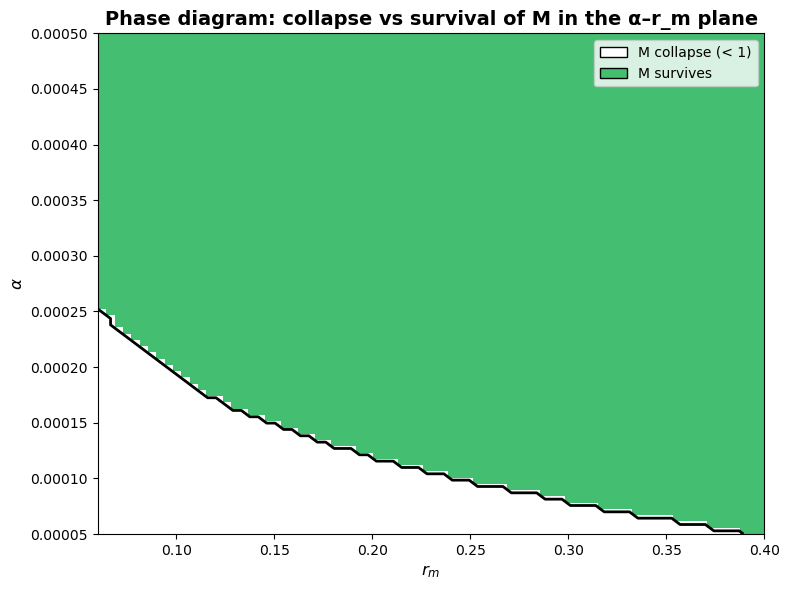

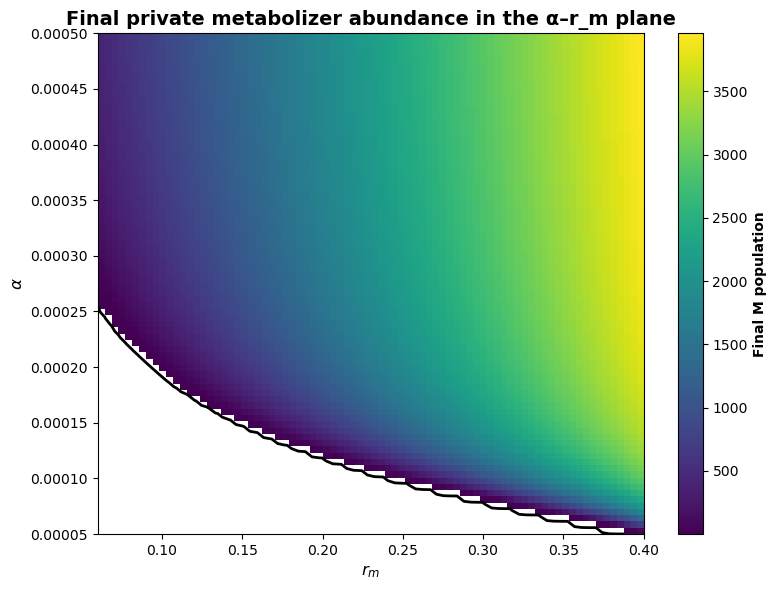

α–β plane
  survival fraction: 0.805
  collapse fraction: 0.195
α–r_p plane
  survival fraction: 0.828
  collapse fraction: 0.172
α–r_m plane
  survival fraction: 0.845
  collapse fraction: 0.155


In [18]:
from src.model import deriv
from src.parameters import parameters

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from matplotlib.colors import ListedColormap, BoundaryNorm
import os
import copy

# ============================================================
# Settings
# ============================================================

os.makedirs("output/figures", exist_ok=True)

# Initial condition and integration grid
y0 = (100.0, 100.0, 100.0)
t = np.linspace(0, 500, 5000)   # longer horizon than before

# Threshold for effective extinction / collapse
collapse_threshold = 1.0

# Baseline parameters from repository
nu_base = parameters["nu"]
beta_base = parameters["beta"]
alpha_base = parameters["alpha"]
r_p_base = parameters["r_p"]
r_m_base = parameters["r_m"]
gamma_base = parameters["gamma"]
eta_base = parameters["eta"]

# Keep a consistent palette with the repository-like viridis family
survival_cmap = ListedColormap(["#ffffff",   # collapse
    plt.get_cmap("viridis")(0.70),  # survival
])
survival_norm = BoundaryNorm([-0.5, 0.5, 1.5], survival_cmap.N)

# ============================================================
# Helpers
# ============================================================

def run_system(nu, beta, alpha, r_p, r_m, gamma, eta, y0=y0, t=t):
    """
    Integrate the ODE system and clip tiny negative numerical artifacts.
    """
    sol = odeint(
        deriv,
        y0,
        t,
        args=(nu, beta, alpha, r_p, r_m, gamma, eta)
    )
    sol = np.maximum(sol, 0.0)
    return sol


def classify_final_state(sol, threshold=collapse_threshold):
    """
    Binary classification based on final population of M:
        0 = collapse
        1 = survival
    """
    M_final = sol[-1, 2]
    return 0 if M_final < threshold else 1


def compute_final_state_metrics(sol):
    """
    Return final and minimum values for P, C, M.
    Useful for debugging and interpretation.
    """
    return {
        "P_final": sol[-1, 0],
        "C_final": sol[-1, 1],
        "M_final": sol[-1, 2],
        "P_min": np.min(sol[:, 0]),
        "C_min": np.min(sol[:, 1]),
        "M_min": np.min(sol[:, 2]),
    }


def scan_parameter_plane(
    x_name, x_values,
    y_name, y_values,
    base_params,
    threshold=collapse_threshold
):
    """
    Scan a 2D parameter plane and classify survival/collapse of M.
    Returns:
        class_map: 0 collapse, 1 survival
        final_M: final M values
        final_P: final P values
        final_C: final C values
    """
    class_map = np.zeros((len(y_values), len(x_values)), dtype=int)
    final_M = np.zeros((len(y_values), len(x_values)))
    final_P = np.zeros((len(y_values), len(x_values)))
    final_C = np.zeros((len(y_values), len(x_values)))

    for i, y_val in enumerate(y_values):
        for j, x_val in enumerate(x_values):
            p = base_params.copy()
            p[x_name] = float(x_val)
            p[y_name] = float(y_val)

            sol = run_system(
                nu=p["nu"],
                beta=p["beta"],
                alpha=p["alpha"],
                r_p=p["r_p"],
                r_m=p["r_m"],
                gamma=p["gamma"],
                eta=p["eta"],
            )

            metrics = compute_final_state_metrics(sol)

            final_P[i, j] = metrics["P_final"]
            final_C[i, j] = metrics["C_final"]
            final_M[i, j] = metrics["M_final"]
            class_map[i, j] = 0 if metrics["M_final"] < threshold else 1

    return class_map, final_P, final_C, final_M


def plot_phase_diagram(
    x_values, y_values, class_map,
    x_label, y_label, title,
    filename
):
    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(
        class_map,
        origin="lower",
        aspect="auto",
        cmap=survival_cmap,
        norm=survival_norm,
        extent=[x_values[0], x_values[-1], y_values[0], y_values[-1]],
        interpolation="nearest",
    )

    # Draw boundary between collapse and survival
    X, Y = np.meshgrid(x_values, y_values)
    ax.contour(
        X, Y, class_map,
        levels=[0.5],
        colors="black",
        linewidths=2.0
    )

    ax.set_xlabel(x_label, fontsize=12, fontweight="bold")
    ax.set_ylabel(y_label, fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold")

    # Manual legend
    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor="#ffffff", edgecolor="black", label=f"M collapse (< {collapse_threshold:g})"),
        Patch(facecolor=plt.get_cmap("viridis")(0.70), edgecolor="black", label="M survives"),
    ]
    ax.legend(handles=handles, loc="best", frameon=True)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def plot_final_M_heatmap(
    x_values, y_values, final_M,
    x_label, y_label, title,
    filename
):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Use viridis and make low-density region explicit
    cmap = copy.copy(plt.get_cmap("viridis"))
    cmap.set_under("white")

    positive = final_M[final_M >= collapse_threshold]
    vmax = positive.max() if positive.size else collapse_threshold * 10

    im = ax.imshow(
        final_M,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        vmin=collapse_threshold,
        vmax=vmax,
        extent=[x_values[0], x_values[-1], y_values[0], y_values[-1]],
        interpolation="nearest",
    )

    X, Y = np.meshgrid(x_values, y_values)
    ax.contour(
        X, Y, final_M,
        levels=[collapse_threshold],
        colors="black",
        linewidths=2.0
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Final M population", fontweight="bold")

    ax.set_xlabel(x_label, fontsize=12, fontweight="bold")
    ax.set_ylabel(y_label, fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# Baseline parameter dictionary
# ============================================================

base_params = {
    "nu": nu_base,
    "beta": beta_base,
    "alpha": alpha_base,
    "r_p": r_p_base,
    "r_m": r_m_base,
    "gamma": gamma_base,
    "eta": eta_base,
}

# ============================================================
# 1) Alpha vs Beta
# ============================================================

alpha_vals = np.linspace(0.5 * beta_base, 5.0 * beta_base, 80)
beta_vals = np.linspace(0.5 * beta_base, 2.0 * beta_base, 80)

class_ab, finalP_ab, finalC_ab, finalM_ab = scan_parameter_plane(
    x_name="beta",
    x_values=beta_vals,
    y_name="alpha",
    y_values=alpha_vals,
    base_params=base_params,
)

plot_phase_diagram(
    x_values=beta_vals,
    y_values=alpha_vals,
    class_map=class_ab,
    x_label=r"$\beta$",
    y_label=r"$\alpha$",
    title="Phase diagram: collapse vs survival of private metabolizer (M) in the α–β plane",
    filename="output/figures/phase_diagram_alpha_beta_M.png",
)

plot_final_M_heatmap(
    x_values=beta_vals,
    y_values=alpha_vals,
    final_M=finalM_ab,
    x_label=r"$\beta$",
    y_label=r"$\alpha$",
    title="Final private metabolizer abundance in the α–β plane",
    filename="output/figures/finalM_alpha_beta.png",
)

# ============================================================
# 2) Alpha vs r_p
# ============================================================

alpha_vals_rp = np.linspace(0.5 * beta_base, 5.0 * beta_base, 80)
r_p_vals = np.linspace(0.3 * r_p_base, 2.0 * r_p_base, 80)

class_arp, finalP_arp, finalC_arp, finalM_arp = scan_parameter_plane(
    x_name="r_p",
    x_values=r_p_vals,
    y_name="alpha",
    y_values=alpha_vals_rp,
    base_params=base_params,
)

plot_phase_diagram(
    x_values=r_p_vals,
    y_values=alpha_vals_rp,
    class_map=class_arp,
    x_label=r"$r_p$",
    y_label=r"$\alpha$",
    title="Phase diagram: collapse vs survival of M in the α–r_p plane",
    filename="output/figures/phase_diagram_alpha_rp_M.png",
)

plot_final_M_heatmap(
    x_values=r_p_vals,
    y_values=alpha_vals_rp,
    final_M=finalM_arp,
    x_label=r"$r_p$",
    y_label=r"$\alpha$",
    title="Final private metabolizer abundance in the α–r_p plane",
    filename="output/figures/finalM_alpha_rp.png",
)

# ============================================================
# 3) Alpha vs r_m
# ============================================================

alpha_vals_rm = np.linspace(0.5 * beta_base, 5.0 * beta_base, 80)
r_m_vals = np.linspace(0.3 * r_m_base, 2.0 * r_m_base, 80)

class_arm, finalP_arm, finalC_arm, finalM_arm = scan_parameter_plane(
    x_name="r_m",
    x_values=r_m_vals,
    y_name="alpha",
    y_values=alpha_vals_rm,
    base_params=base_params,
)

plot_phase_diagram(
    x_values=r_m_vals,
    y_values=alpha_vals_rm,
    class_map=class_arm,
    x_label=r"$r_m$",
    y_label=r"$\alpha$",
    title="Phase diagram: collapse vs survival of M in the α–r_m plane",
    filename="output/figures/phase_diagram_alpha_rm_M.png",
)

plot_final_M_heatmap(
    x_values=r_m_vals,
    y_values=alpha_vals_rm,
    final_M=finalM_arm,
    x_label=r"$r_m$",
    y_label=r"$\alpha$",
    title="Final private metabolizer abundance in the α–r_m plane",
    filename="output/figures/finalM_alpha_rm.png",
)

# ============================================================
# Optional: print a quick summary
# ============================================================

def report_fraction_survival(name, class_map):
    frac_survival = np.mean(class_map == 1)
    frac_collapse = np.mean(class_map == 0)
    print(f"{name}")
    print(f"  survival fraction: {frac_survival:.3f}")
    print(f"  collapse fraction: {frac_collapse:.3f}")

report_fraction_survival("α–β plane", class_ab)
report_fraction_survival("α–r_p plane", class_arp)
report_fraction_survival("α–r_m plane", class_arm)

#  Parameter sensivity analysis(supplementary material)

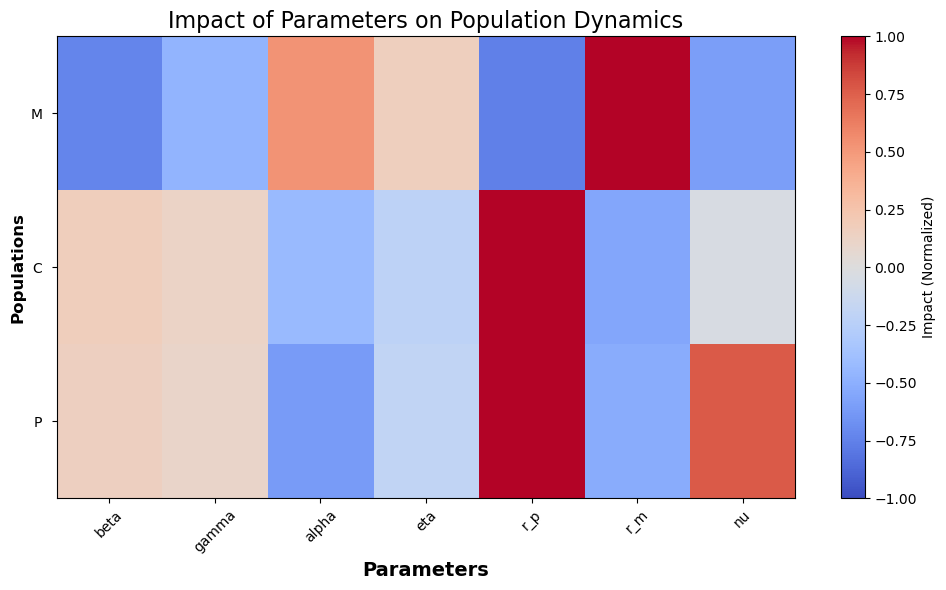

In [ ]:
# Simulation configuration
simulation_config = {
    't_max': 200,  # Maximum simulation time
    'dt': 0.1,  # Time step
    'rp_rm_range': np.linspace(1, 3.0, 10),  # Parameter perturbation range
}

# Initial conditions and time vector
y0 = 100.0, 10.0, 100.0  # Initial populations of [C (Public), D (Cheater), P (Private)]
t_max, dt = simulation_config['t_max'], simulation_config['dt']  # Extract simulation settings
t = np.linspace(0, t_max, int(t_max / dt))  # Time vector for simulation

# Solve ODE system
ret = odeint(deriv, y0, t, args=(
    parameters["nu"],
    parameters["beta"],
    parameters["alpha"],
    parameters["r_p"],
    parameters["r_m"],
    parameters["gamma"],
    parameters["eta"],
))

# Extract growth rates 
P, C, M = ret[:, 0], ret[:, 1], ret[:, 2]

# Relative Contributions of Parameters (Metabolic Control Analysis)
def perform_metabolic_control_analysis():
    
    parameter_names = [param for param in parameters.keys() if param not in ["sigma_p", "sigma_m"]]
    impact_matrix = np.zeros((3, len(parameter_names)))  # Rows: Populations, Columns: Parameters

    for j, param_name in enumerate(parameter_names):
        impacts = []

        for factor in simulation_config['rp_rm_range']:
            # Perturb parameter
            perturbed_params = parameters.copy()
            perturbed_params[param_name] *= factor
            ret_perturbed = odeint(src.model.deriv, y0, t, args=(
                perturbed_params["nu"],
                perturbed_params["beta"],
                perturbed_params["alpha"],
                perturbed_params["r_p"],
                perturbed_params["r_m"],
                perturbed_params["gamma"],
                perturbed_params["eta"],
            ))
            P_perturbed, C_perturbed, M_perturbed = ret_perturbed[:, 0], ret_perturbed[:, 1], ret_perturbed[:, 2]

            # Calculate relative impacts for populations
            impacts.append([
                (np.sum(P_perturbed)- np.sum(P)) / np.sum(P) if np.sum(P_perturbed) != 0 else 0,
                ( np.sum(C_perturbed)- np.sum(C)) / np.sum(C)  if np.sum(C_perturbed) != 0 else 0,
                ( np.sum(M_perturbed) - np.sum(M) ) / np.sum(M) if np.sum(M_perturbed) != 0 else 0,
            ])

        # Average impact over the range
        impact_matrix[:, j] = np.mean(impacts, axis=0)

    return impact_matrix, parameter_names

impact_matrix, parameter_names = perform_metabolic_control_analysis()

# Plotting the Heatmap
def plot_impact_heatmap(impact_matrix, parameter_names):
    
    plt.figure(figsize=(10, 6))
    plt.imshow(impact_matrix, aspect='auto', cmap='coolwarm', origin='lower', vmin=-1, vmax=1)
    plt.colorbar(label='Impact (Normalized)')
    plt.xticks(range(len(parameter_names)), labels=parameter_names, rotation=45)
    plt.yticks(range(3), labels=['P ', 'C ', 'M '])
    plt.title('Impact of Parameters on Population Dynamics', fontsize=16)
    plt.xlabel('Parameters', fontsize=14, fontweight="bold")
    plt.ylabel('Populations', fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("output/impact_heatmap.png", dpi=300)
    plt.show()

# Execute heatmap plotting
plot_impact_heatmap(impact_matrix, parameter_names)


In [22]:
# ====================== STEADY-STATE SOLVER ======================
def compute_steady_state(params_dict, t_max=2000, n_points=20000):
    y0 = [1.0, 0.5, 0.5]                    # reasonable starting point
    t = np.linspace(0, t_max, n_points)
    
    sol = odeint(src.model.deriv, y0, t, args=(
        params_dict["nu"], params_dict["beta"],
        params_dict["alpha"], params_dict["r_p"],
        params_dict["r_m"], params_dict["gamma"], params_dict["eta"]
    ))
    
    steady = sol[-1]                        # last point
    # Optional: check convergence
    if np.max(np.abs(np.diff(sol[-100:], axis=0))) > 1e-6:
        print(f"  Warning: possible non-convergence for {params_dict}")
    
    return steady

# ====================== BASELINE ======================
baseline = compute_steady_state(parameters)
P_star, C_star, M_star = baseline
print(f"Baseline steady state (P*, C*, M*): {baseline}")

# ====================== SENSITIVITY LOOP ======================
vary_params = ["nu", "beta", "alpha", "r_p", "r_m", "gamma", "eta"]
factors     = [0.5, 0.8, 1.2, 1.5]

results = []

for param_name in vary_params:
    for factor in factors:
        test_params = parameters.copy()
        test_params[param_name] *= factor
        
        # Feasibility check (D > 0)
        D = (test_params["alpha"]**2 * test_params["gamma"] +
             test_params["nu"] * test_params["eta"] * test_params["gamma"] -
             test_params["nu"] * test_params["beta"]**2)
        if D <= 0:
            continue
        
        steady_new = compute_steady_state(test_params)
        P_new, C_new, M_new = steady_new
        
        rel_P = 100 * (P_new - P_star) / P_star if P_star > 1e-8 else np.nan
        rel_C = 100 * (C_new - C_star) / C_star if C_star > 1e-8 else np.nan
        rel_M = 100 * (M_new - M_star) / M_star if M_star > 1e-8 else np.nan
        
        results.append({
            "Parameter": param_name,
            "Factor": factor,
            "ΔP* (%)": round(rel_P, 1),
            "ΔC* (%)": round(rel_C, 1),
            "ΔM* (%)": round(rel_M, 1)
        })

# ====================== OUTPUT ======================
df = pd.DataFrame(results)
print("\n=== One-at-a-time Sensitivity Analysis ===")
print(df.to_string(index=False))

# Save for the repository
df.to_csv("sensitivity_analysis_results.csv", index=False)
print("\nResults saved to sensitivity_analysis_results.csv")
print("You can now upload this file (and the script) to the GitHub repo.")

Baseline steady state (P*, C*, M*): [ 750. 1500. 1250.]

=== One-at-a-time Sensitivity Analysis ===
Parameter  Factor  ΔP* (%)  ΔC* (%)  ΔM* (%)
       nu     0.5    -50.0      0.0     30.0
       nu     0.8    -20.0      0.0     12.0
       nu     1.2     20.0     -0.0    -12.0
       nu     1.5     50.0     -0.0    -30.0
     beta     0.5     12.3     12.3     26.3
     beta     0.8      4.0      4.0     10.1
     beta     1.2     -2.6     -2.6    -10.1
     beta     1.5     -3.0     -3.0    -27.3
    alpha     0.5    233.3     66.7   -100.0
    alpha     0.8     56.2     25.0    -33.7
    alpha     1.2    -30.6    -16.7     18.3
    alpha     1.5    -55.6    -33.3     33.3
      r_p     0.5    -83.3    -83.3     50.0
      r_p     0.8    -33.3    -33.3     20.0
      r_p     1.2     33.3     33.3    -20.0
      r_p     1.5     83.3     83.3    -50.0
      r_m     0.5     33.3     33.3   -100.0
      r_m     0.8     13.3     13.3    -40.0
      r_m     1.2    -13.3    -13.3     40.0
